# **Data Visualitation**

##### 1. Introduction
##### 2. Import and Prepare th Dataset

In [1]:
import pandas as pd
import numpy as np
import janitor

ecomm_df = pd.read_csv("https://goo.gl/hzRyFd")
ecomm_df = ecomm_df.clean_names()

ecomm_df.head(5)

,datetime,country,city,region,screenred,surveytype,purposeproductinfo,purposebuyfromsite,purposecomparepricing,purposeinfoandresources,...,behavreferral,behavpageviews,behavhomepage,behavdetailproda,behavdetailprodb,behavdetailprodc,behavanysolution,behavanysale,behavcart,behavconversion
0,7/25/2014 14:10,United States,Monroe,LA,1280x1024,At Exit,Products,NaN,NaN,Resources,...,Direct,4 to 6,1,1,0,0,0,0,0,0
1,7/25/2014 15:01,United States,Ambler,PA,1280x800,At Exit,NaN,Buy from this site,Compare pricing,NaN,...,Unbranded Search,1,0,0,0,0,0,0,0,0
2,7/25/2014 15:15,United States,Beaumont,TX,768x1024,At Exit,NaN,NaN,Compare pricing,NaN,...,Unbranded Search,10+,0,0,0,0,1,1,0,0
3,7/25/2014 17:05,United States,Cedar City,UT,1280x960,At Exit,Products,NaN,NaN,NaN,...,Unbranded Search,10+,0,1,1,0,1,0,0,0
4,7/26/2014 0:27,United States,Bullhead City,AZ,1138x640,At Exit,NaN,NaN,NaN,Resources,...,Referred,1,0,0,0,0,0,0,0,0


##### Pre-processing

In [2]:
# Count missing values in each column
ecomm_df.isna().sum()

datetime                          0
country                           0
city                             36
region                           24
screenred                         0
surveytype                        0
purposeproductinfo              500
purposebuyfromsite             1094
purposecomparepricing          1210
purposeinfoandresources        1072
purposeinfoonorder             1580
purposeother                   1526
taskfindwhatlookingfor          682
concernshippingcost            1521
concerndeliveryspeed           1568
concernwarranties              1561
concerneasetoreturnproduct     1532
concernproductsafety           1579
concernrightformychild         1494
concernproductquality          1538
concernproducteffectiveness    1508
concernother                   1583
concernnone                    1484
intentwasplanningtobuy         1095
profile                           0
whensiteused                     53
purchasedbefore                 976
purchasedwhen               

In [3]:
# View value distribution
ecomm_df['behavpageviews'].value_counts().sort_index()

behavpageviews
0           5
1         251
10+       581
2 to 3    256
4 to 6    301
7 to 9    199
Name: count, dtype: int64

In [4]:
# Conservative mapping for each bin
def convert_pageviews(x):
    mapping = {
        "1": 1,
        "2 to 3": 2,
        "4 to 6": 4,
        "7 to 9": 7,
        "10+": 10
    }
    return mapping.get(x, None)

# Add new integer variable
ecomm_df['behav_pageviews_int'] = ecomm_df['behavpageviews'].apply(convert_pageviews)
# Quick check
ecomm_df['behav_pageviews_int'].describe()

count    1588.000000
mean        5.774559
std         3.636725
min         1.000000
25%         2.000000
50%         4.000000
75%        10.000000
max        10.000000
Name: behav_pageviews_int, dtype: float64

##### 3. Univariate Visualitation Techniques

    3.1 Categorical Variables

Bar Chart

In [5]:
# Create a frequency table
profile_counts = ecomm_df['profile'].value_counts().sort_index()
profile_counts

profile
0                              1
Friend/family friend          23
Health Professional          277
Other                        134
Parent                       776
Person with [condition A]     52
Relative                     107
Teacher                      223
Name: count, dtype: int64

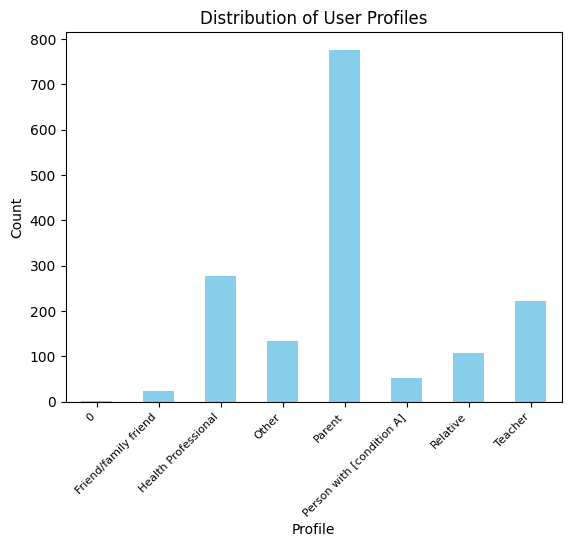

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a horizontal barplot
profile_counts.plot(kind="bar", color="skyblue")
plt.title("Distribution of User Profiles")
plt.xlabel("Profile")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.show()

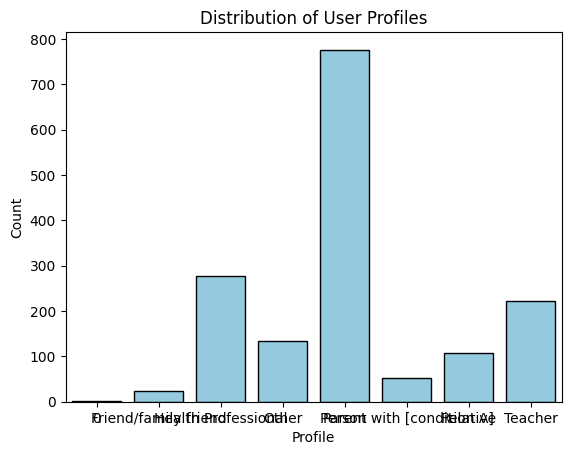

In [7]:
sns.countplot(data=ecomm_df, x="profile", color="skyblue", edgecolor="black", order=sorted(ecomm_df['profile'].unique()))
plt.title("Distribution of User Profiles")
plt.xlabel("Profile")
plt.ylabel("Count")
plt.show()

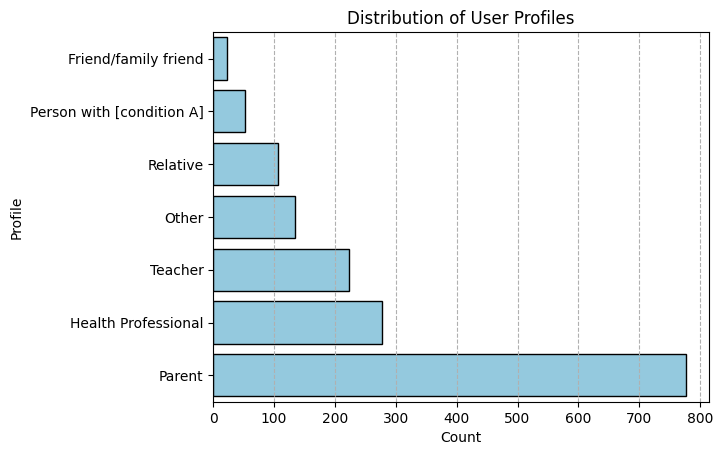

In [8]:
ecomm_df_filtered = ecomm_df[ecomm_df['profile'] != "0"]
sns.countplot(data=ecomm_df_filtered, y="profile", 
              color="skyblue", edgecolor="black", order=ecomm_df_filtered['profile'].value_counts().index[::-1])
plt.title("Distribution of User Profiles")
plt.xlabel("Count")
plt.ylabel("Profile")
plt.grid(axis="x", linestyle="--")
plt.show()

Pie Chart

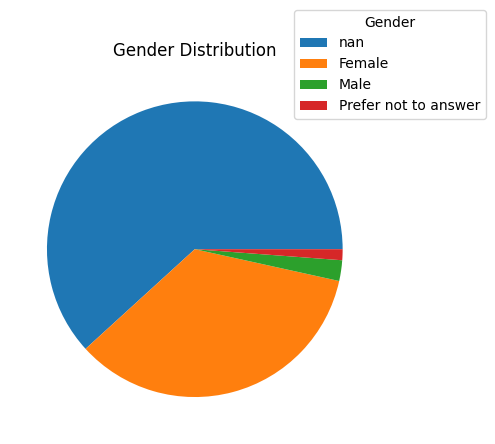

In [9]:
# Create a frequency table of gender
gender_counts = ecomm_df['gender'].value_counts(dropna=False)

# Create a pie chart
gender_counts.plot(kind="pie", labels=None)
plt.title("Gender Distribution")
plt.ylabel("")
plt.legend(labels=gender_counts.index, title="Gender", loc="center left", bbox_to_anchor=(0.75,1))
plt.show()

    3.2. Continuous Variables

Histogram

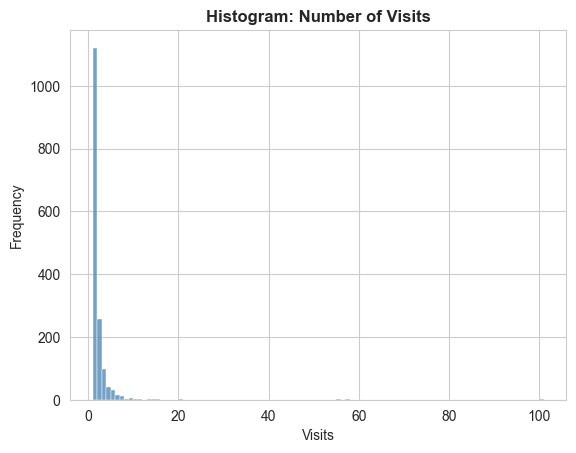

In [10]:
sns.set_style("whitegrid") #white, dark, whitegrid, darkgrid
sns.histplot(data=ecomm_df, x="behavnumvisits", binwidth=1, color="steelblue", edgecolor="white", bins=50)
plt.title("Histogram: Number of Visits", fontweight="bold")
plt.xlabel("Visits")
plt.ylabel("Frequency")
plt.show()

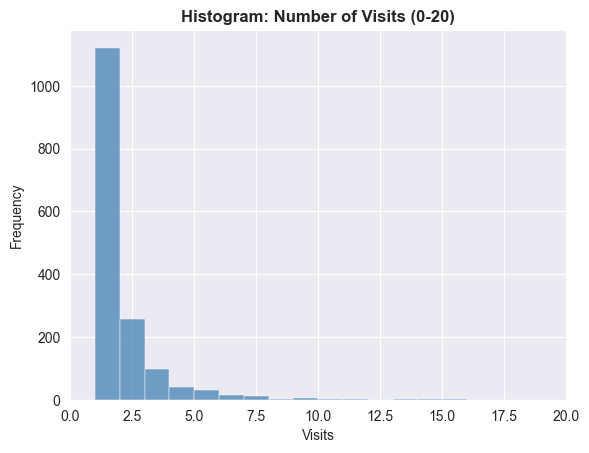

In [11]:
sns.set_style("darkgrid") #white, dark, whitegrid, darkgrid
sns.histplot(data=ecomm_df, x="behavnumvisits", binwidth=1, color="steelblue", edgecolor="white", bins=50)
plt.xlim([0,20])
plt.title("Histogram: Number of Visits (0-20)", fontweight="bold")
plt.xlabel("Visits")
plt.ylabel("Frequency")
plt.show()

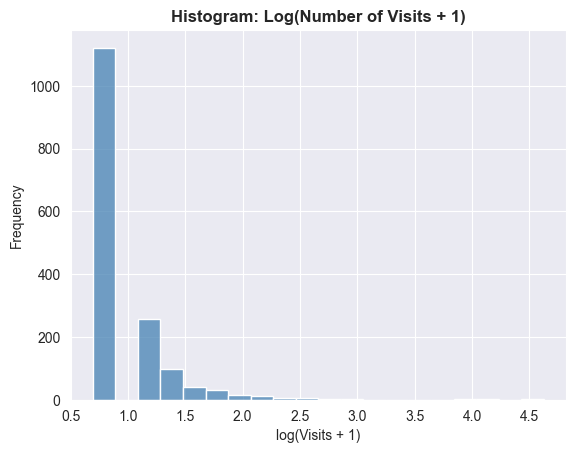

In [12]:
# Use a log-transformed x-axis to reduce skew

sns.set_style("darkgrid")
sns.histplot(x=np.log1p(ecomm_df["behavnumvisits"]), binwidth=0.2, color="steelblue", edgecolor="white", bins=50)
plt.title("Histogram: Log(Number of Visits + 1)", fontweight="bold")
plt.xlabel("log(Visits + 1)")
plt.ylabel("Frequency")
plt.show()

Density Plot

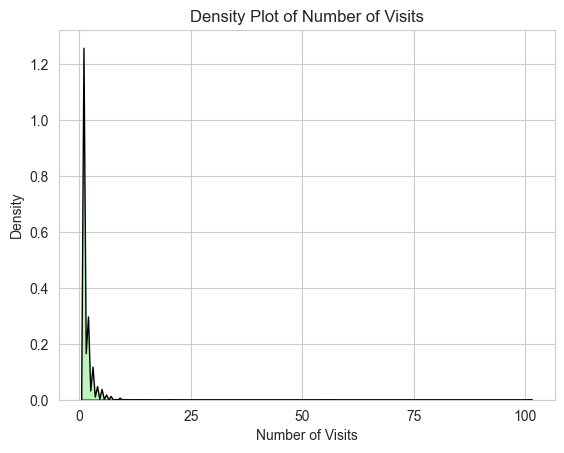

In [13]:
sns.set_style("whitegrid")
sns.kdeplot(data=ecomm_df, x='behavnumvisits', fill=True, edgecolor="black", color="lightgreen", alpha=0.6, bw_adjust=0.25)
plt.title("Density Plot of Number of Visits")
plt.xlabel("Number of Visits")
plt.xticks(np.arange(0,101,25))
plt.ylabel("Density")
plt.show()

Box Plot

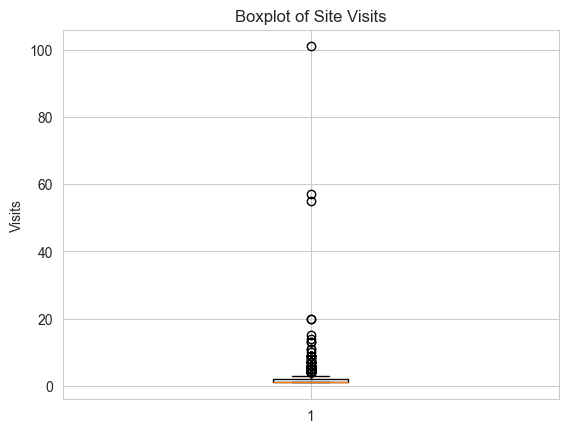

In [14]:
plt.boxplot(x=ecomm_df['behavnumvisits'], orientation='vertical')
plt.title("Boxplot of Site Visits")
plt.ylabel("Visits")
plt.show()

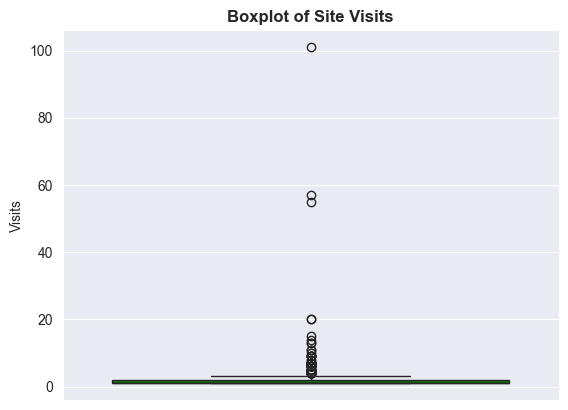

In [15]:
sns.set_style("darkgrid")
sns.boxplot(y=ecomm_df['behavnumvisits'], color="green")
plt.title("Boxplot of Site Visits", fontweight='bold')
plt.ylabel("Visits")
plt.show()

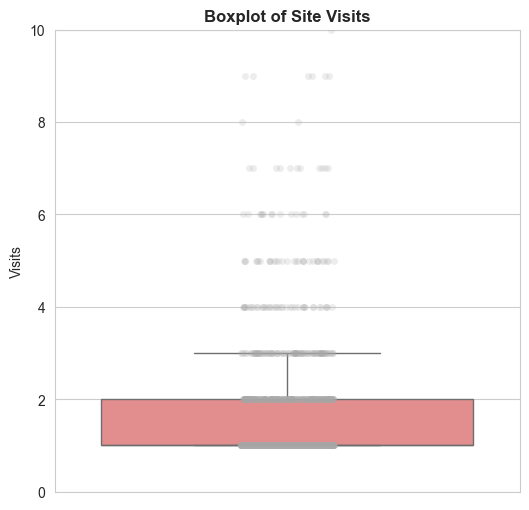

In [16]:
plt.figure(figsize=(6,6))
sns.set_style("whitegrid")
sns.boxplot(y=ecomm_df['behavnumvisits'], color='lightcoral', showfliers=False)
sns.stripplot(y=ecomm_df['behavnumvisits'], color='darkgrey', alpha=0.2, jitter=True)
plt.ylim([0,10])
plt.title("Boxplot of Site Visits", fontweight='bold')
plt.xlabel("")
plt.ylabel("Visits")
plt.show()

##### 4. Multivariate Visualization Techniques

4.1. Categorical vs. Categorical

Crosstab

In [17]:
pd.crosstab(ecomm_df['profile'], ecomm_df['gender'])

gender,Female,Male,Prefer not to answer
profile,,,
Friend/family friend,5,0,1
Health Professional,126,3,4
Other,41,2,2
Parent,256,24,5
Person with [condition A],13,1,6
Relative,36,3,1
Teacher,77,3,0


In [18]:
pd.crosstab(ecomm_df['profile'], ecomm_df['gender'], normalize='index')*100

gender,Female,Male,Prefer not to answer
profile,,,
Friend/family friend,83.333333,0.000000,16.666667
Health Professional,94.736842,2.255639,3.007519
Other,91.111111,4.444444,4.444444
Parent,89.824561,8.421053,1.754386
Person with [condition A],65.000000,5.000000,30.000000
Relative,90.000000,7.500000,2.500000
Teacher,96.250000,3.750000,0.000000


In [19]:
pd.crosstab(ecomm_df['profile'], ecomm_df['gender'], normalize='columns')

gender,Female,Male,Prefer not to answer
profile,,,
Friend/family friend,0.009025,0.000000,0.052632
Health Professional,0.227437,0.083333,0.210526
Other,0.074007,0.055556,0.105263
Parent,0.462094,0.666667,0.263158
Person with [condition A],0.023466,0.027778,0.315789
Relative,0.064982,0.083333,0.052632
Teacher,0.138989,0.083333,0.000000


Grouped Bar Chart

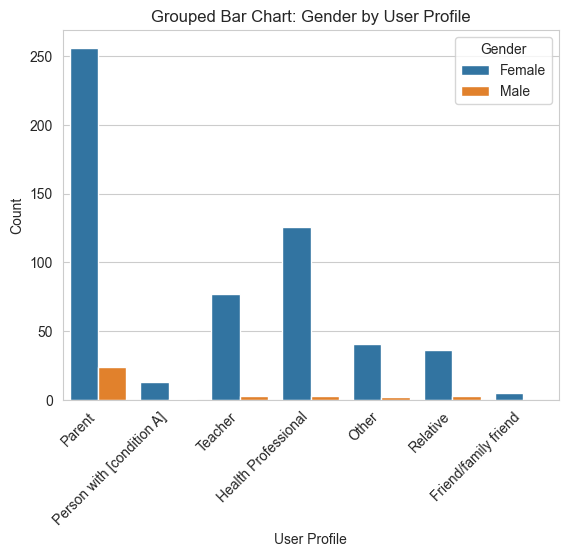

In [20]:
ecomm_df_filt = ecomm_df[(ecomm_df['profile'] != '0') & 
                         (ecomm_df['profile'].notna()) & 
                         (ecomm_df['gender'] != "Prefer not to answer") & 
                         (ecomm_df['gender'].notna())]

sns.countplot(data=ecomm_df_filt, x='profile', hue='gender', dodge=True)
plt.title("Grouped Bar Chart: Gender by User Profile")
plt.xlabel("User Profile")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Gender")
plt.show()

Stacked Bar Chart

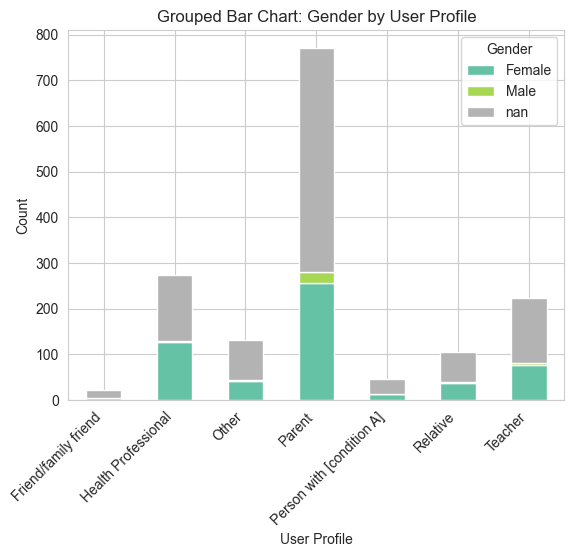

In [21]:
ecomm_df_filt = ecomm_df[(ecomm_df['profile'] != '0') & 
                         (ecomm_df['profile'].notna()) & 
                         (ecomm_df['gender'] != "Prefer not to answer")]

table = pd.crosstab(ecomm_df_filt['profile'],ecomm_df_filt['gender'], dropna=False)

table.plot(kind='bar', stacked=True, colormap="Set2")
plt.title("Grouped Bar Chart: Gender by User Profile")
plt.xlabel("User Profile")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Gender")
plt.show()

Proportional Stacked Bar Chart

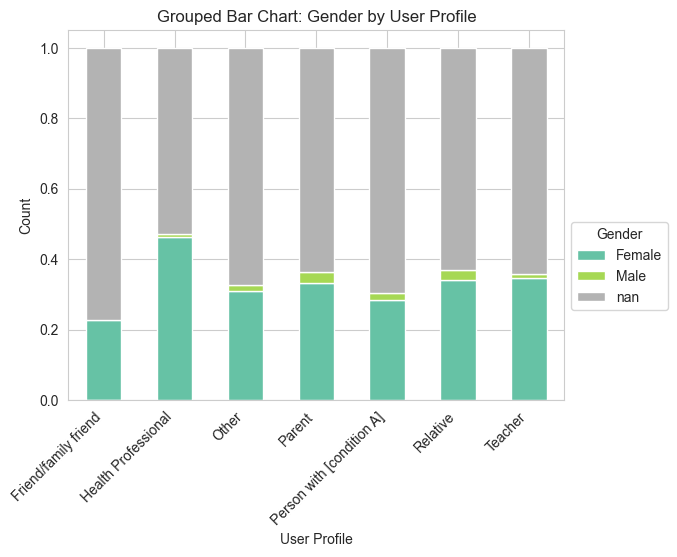

In [22]:
table_prop = table.div(table.sum(axis=1), axis=0)

table_prop.plot(kind='bar', stacked=True, colormap="Set2")

plt.title("Grouped Bar Chart: Gender by User Profile")
plt.xlabel("User Profile")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Gender", bbox_to_anchor=(1,0.5))
plt.show()

**Advanced Version: The best visualization type for these two variables**

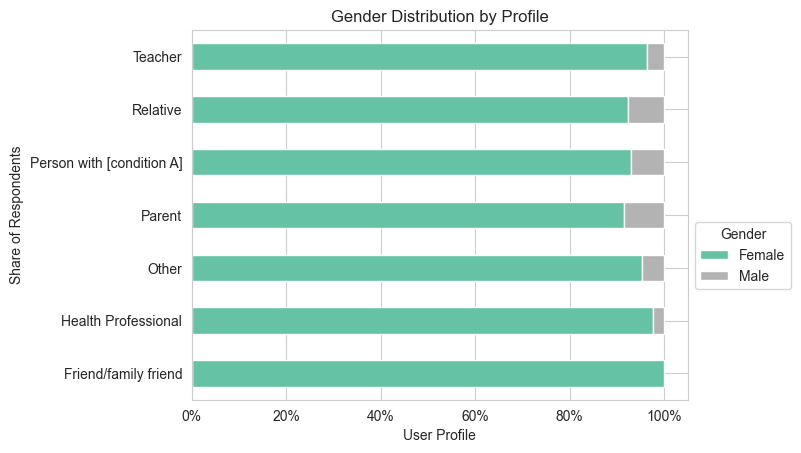

In [23]:
import matplotlib.ticker as mtick

ecomm_df_filt = ecomm_df[(ecomm_df['profile'] != '0') & 
                         (ecomm_df['profile'].notna()) & 
                         (ecomm_df['gender'] != "Prefer not to answer") &
                         (ecomm_df['gender'].notna())]

table = pd.crosstab(ecomm_df_filt['profile'],ecomm_df_filt['gender'], dropna=False)

table_prop = table.div(table.sum(axis=1), axis=0)

ax = table_prop.plot(kind='barh', stacked=True, colormap="Set2")

ax.set_title("Gender Distribution by Profile")
ax.set_xlabel("User Profile")
ax.set_ylabel("Share of Respondents")
ax.legend(title="Gender", bbox_to_anchor=(1,0.5))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.show()

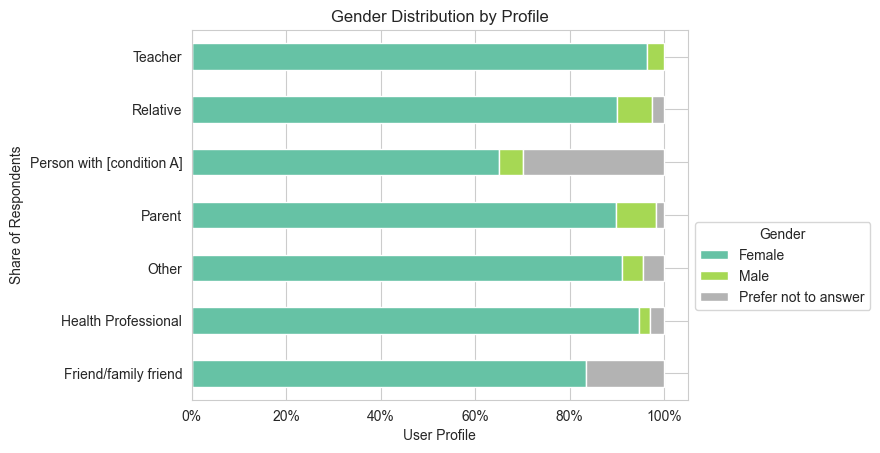

In [24]:
ecomm_df_filt = ecomm_df[(ecomm_df['profile'] != '0') & 
                         (ecomm_df['profile'].notna()) &
                         (ecomm_df['gender'].notna())]

table = pd.crosstab(ecomm_df_filt['profile'],ecomm_df_filt['gender'], dropna=False)

table_prop = table.div(table.sum(axis=1), axis=0)

ax = table_prop.plot(kind='barh', stacked=True, colormap="Set2")

ax.set_title("Gender Distribution by Profile")
ax.set_xlabel("User Profile")
ax.set_ylabel("Share of Respondents")
ax.legend(title="Gender", bbox_to_anchor=(1,0.5))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.show()

4.2. Continuous vs. Continuous

Scatter Plot

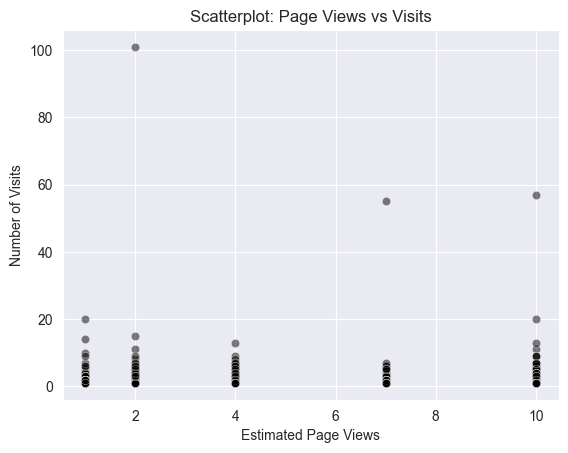

In [25]:
sns.set_style('darkgrid')
sns.scatterplot(data=ecomm_df, x='behav_pageviews_int', y='behavnumvisits', color='black', alpha=0.5)
plt.title("Scatterplot: Page Views vs Visits")
plt.xlabel("Estimated Page Views")
plt.ylabel("Number of Visits")
plt.show()

Jittered Scatter Plot

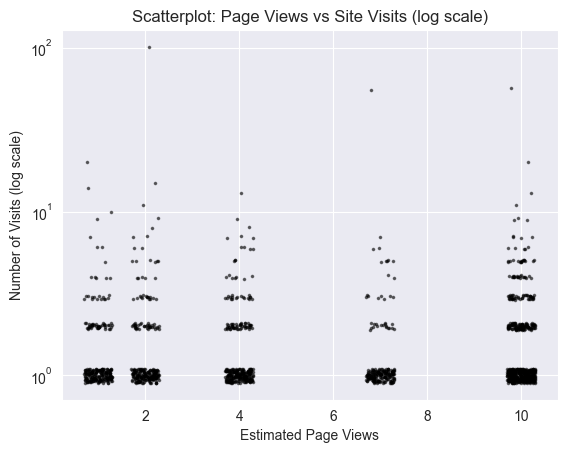

In [26]:
x1 = ecomm_df['behav_pageviews_int'].values
y1 = ecomm_df['behavnumvisits'].values

x_jitter = x1 + np.random.uniform(-0.3, 0.3, len(x1))
y_jitter = y1 + np.random.uniform(-0.1, 0.1, len(y1))

sns.set_style('darkgrid')
plt.scatter(x=x_jitter, y=y_jitter, color='black', alpha=0.5, s=2.5)
plt.yscale('log')
plt.title("Scatterplot: Page Views vs Site Visits (log scale)")
plt.xlabel("Estimated Page Views")
plt.ylabel("Number of Visits (log scale)")
plt.show()

Scatter Plot with Trend Line

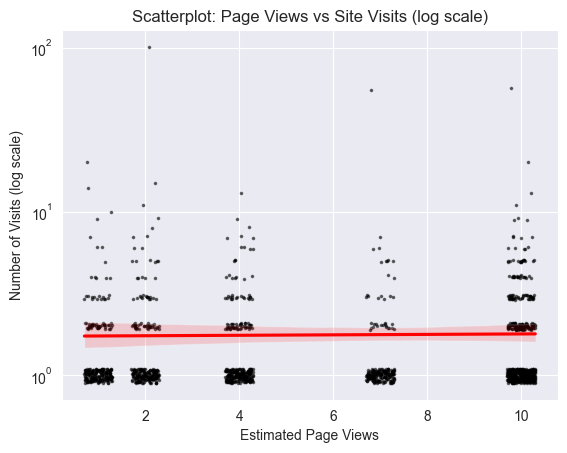

In [27]:
sns.set_style('darkgrid')
sns.regplot(x=x_jitter, y=y_jitter, 
            scatter_kws={'color':'black', 'alpha': 0.5, 's': 2.5}, 
            line_kws={'color': 'red'})
plt.yscale('log')
plt.title("Scatterplot: Page Views vs Site Visits (log scale)")
plt.xlabel("Estimated Page Views")
plt.ylabel("Number of Visits (log scale)")
plt.show()

Correlation Heatmap

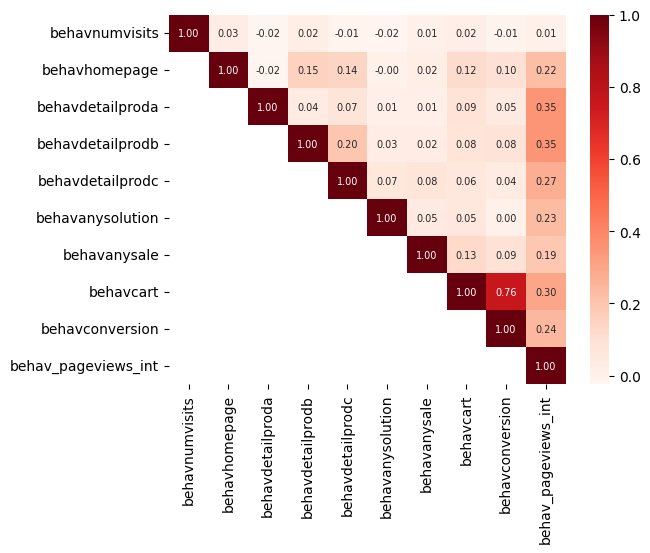

In [28]:
selected_vars = ecomm_df.filter(like="behav").select_dtypes("number")

cor_matrix = selected_vars.dropna().corr()
mask = np.tril(np.ones_like(cor_matrix, dtype='bool'), k=-1)
sns.reset_defaults()
# Plot correlation heatmap
sns.heatmap(cor_matrix,
            mask=mask,
            annot=True,
            fmt=".2f",
            annot_kws={'size': 7},
            cmap="Reds")
plt.show()

4.3. Categorical vs. Continuous

Boxplot by Group

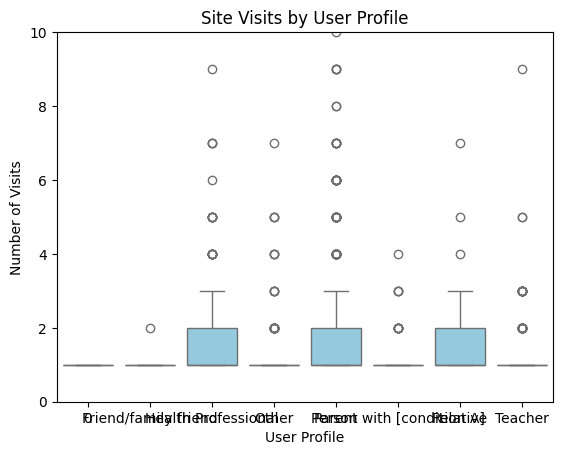

In [29]:
sns.boxplot(data=ecomm_df, x='profile', y='behavnumvisits', color="skyblue", order=sorted(ecomm_df['profile'].unique()))
plt.ylim([0,10])
plt.title("Site Visits by User Profile")
plt.xlabel("User Profile")
plt.ylabel("Number of Visits")
plt.show()

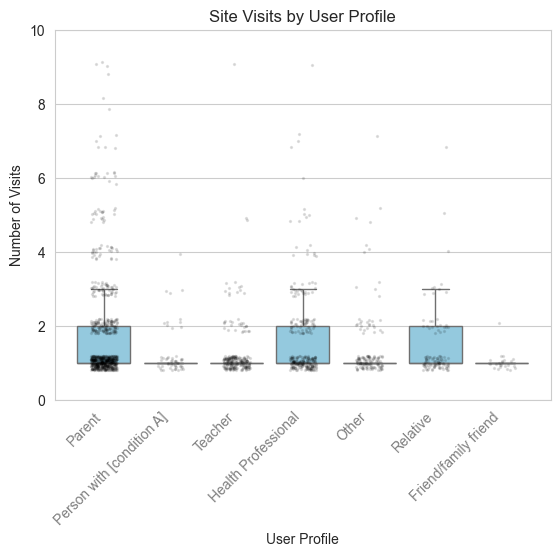

In [30]:
ecomm_df_filt_0 = ecomm_df[(ecomm_df['profile'] != "0")]

x2 = ecomm_df_filt_0['profile']
y2 = ecomm_df_filt_0['behavnumvisits']

categories = list(ecomm_df_filt_0['profile'].unique())
x_post = [categories.index(cat) for cat in x2]

x2_jitter = np.array(x_post) + np.random.uniform(-0.2, 0.2, len(x_post))
y2_jitter = y2 + np.random.uniform(-0.2, 0.2, len(y2))

sns.set_style('whitegrid')
sns.boxplot(data=ecomm_df_filt_0, x='profile', y='behavnumvisits', color="skyblue", showfliers=False, zorder=1)
plt.scatter(x2_jitter, y2_jitter, color="black", alpha=0.1, s=2, zorder=2)
plt.ylim([0,10])
plt.title("Site Visits by User Profile")
plt.xlabel("User Profile")
plt.ylabel("Number of Visits")
plt.xticks(range(len(categories)), rotation=45, color="grey", ha="right")
plt.show()

Mean Bar Chart

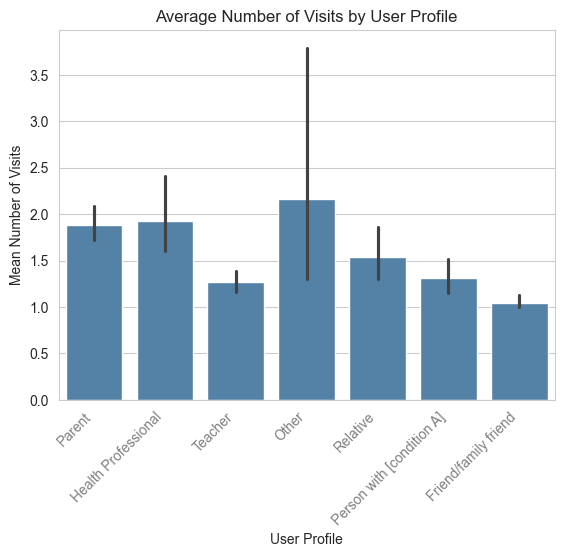

In [42]:
ecomm_df_filt_1 = ecomm_df[(ecomm_df['profile'] != "0") &
                           (ecomm_df['profile'].notna())]

sns.set_style("whitegrid")
sns.barplot(data=ecomm_df_filt_1, x='profile', y='behavnumvisits', estimator=np.mean, 
            order=ecomm_df_filt_1['profile'].value_counts().index, color="steelblue")
plt.title("Average Number of Visits by User Profile")
plt.xlabel("User Profile")
plt.ylabel("Mean Number of Visits")
plt.xticks(rotation=45, ha="right", color="grey")
plt.show()

Faceted Plots

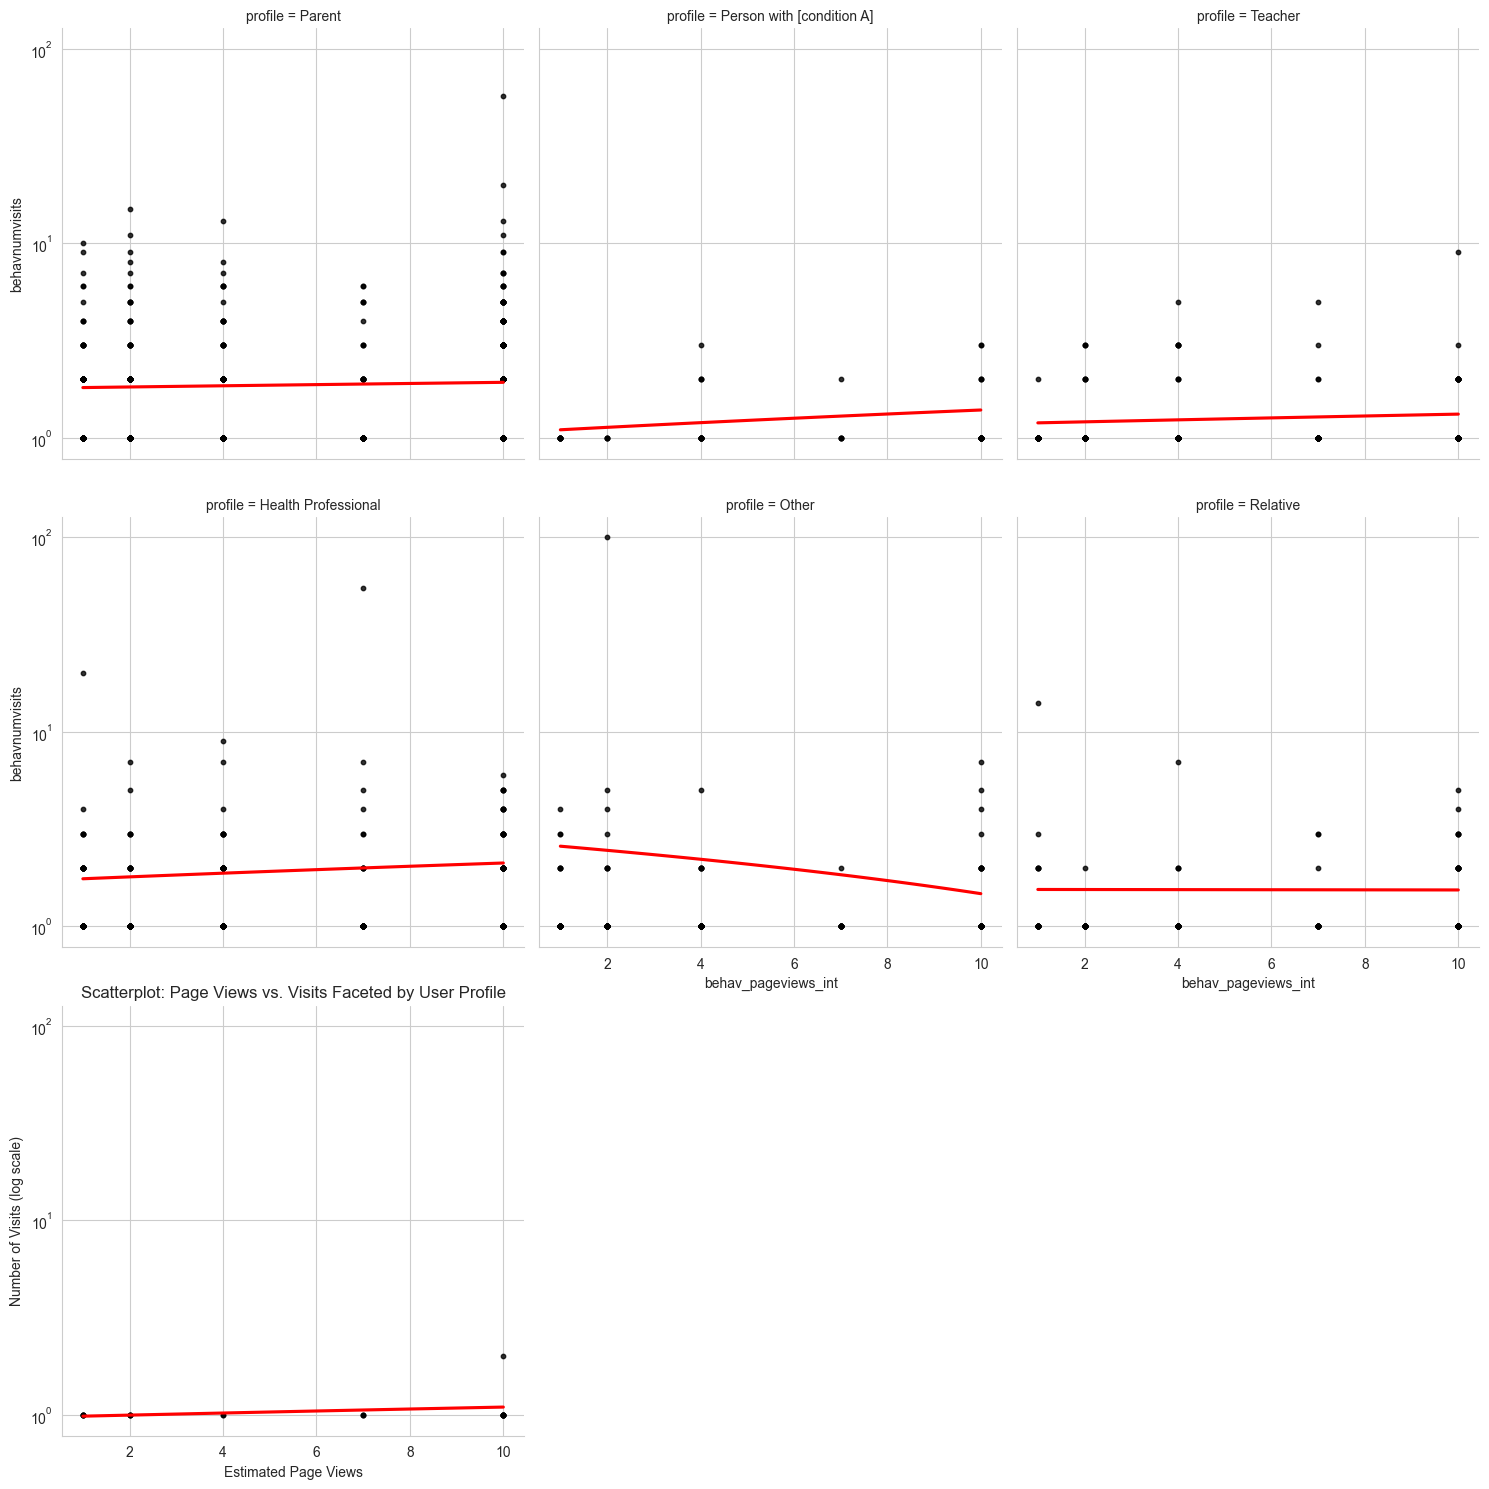

In [ ]:
ecomm_df['behavnumvisits']

#sns.scatterplot(data=ecomm_df_filt_0, x='behav_pageviews_int', y="behavnumvisits", color="black")
sns.lmplot(data=ecomm_df_filt_0, x='behav_pageviews_int', y="behavnumvisits", col="profile", col_wrap=3, 
            scatter=True, ci=None, scatter_kws={"color": "black", "s": 10}, line_kws={"color": "red"})
plt.title("Scatterplot: Page Views vs. Visits Faceted by User Profile")
plt.yscale("log")
plt.xlabel("Estimated Page Views") #ajustar a general
plt.ylabel("Number of Visits (log scale)") # ajustar a general
plt.show()

Line plot (Variables over Time)

In [53]:
ecomm_df['date'] = pd.to_datetime(ecomm_df['datetime'], format="%m/%d/%Y %H:%M")
ecomm_df['date'] = ecomm_df['date'].dt.date

daily_visits = (ecomm_df.groupby('date', as_index=False).agg(total_visits=('behavnumvisits', "sum")))

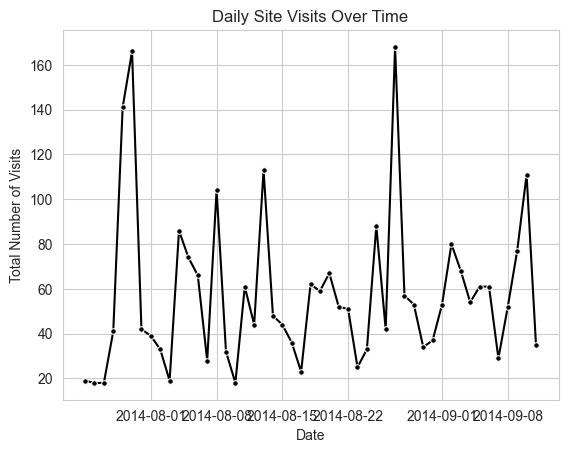

In [62]:
sns.lineplot(data=daily_visits, x='date', y='total_visits', color="black", marker="o", markersize=4)
plt.title("Daily Site Visits Over Time")
plt.xlabel("Date")
plt.ylabel("Total Number of Visits")
plt.show()